# Bmad -> Impact-T for `sc_inj`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pytao import Tao
from pmd_beamphysics import FieldMesh
from impact import fieldmaps
import numpy as np
from copy import deepcopy
import os

In [3]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Bmad 

In [4]:
MODEL = '$LCLS_LATTICE/bmad/models/sc_inj/'
SLICE = 'BEGINNING:LHBEGB'

In [5]:
%%time
INIT = f'-init {MODEL}/tao.init -noplot  -slice {SLICE} '
tao = Tao(INIT)

CPU times: user 22.2 s, sys: 274 ms, total: 22.4 s
Wall time: 22.5 s


In [6]:
# Test
# X_OFFSET = 1e-6
# Y_OFFSET = -2e-6
# tao.cmd(f'set ele SOL1B x_offset = {X_OFFSET}')
# tao.cmd(f'set ele SOL1B y_offset = {Y_OFFSET}')

# solrf

In [7]:
from impact.interfaces.bmad import tao_create_impact_solrf_ele, tao_create_impact_quadrupole_ele
    
res2 =  tao_create_impact_solrf_ele(tao, 'BUN1B', style='derivatives')
res2['line']

v=c acceleating voltage per max field 0.1171197492023345 (V/(V/m))


'0.3 0 0 105 0.659116 1800000.0 1300000000.0 216.76311786748968 666 0.15 0.0 0.0 0 0 0 0 /name:BUN1B'

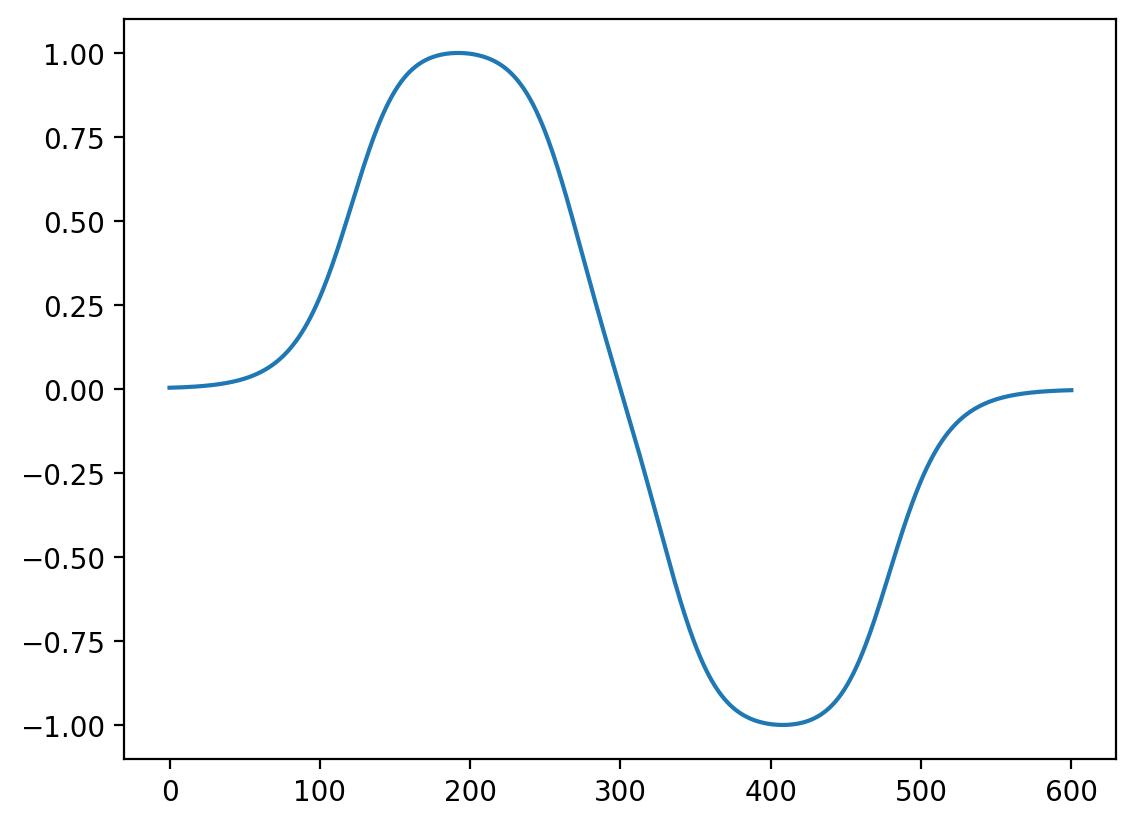

In [8]:
darray = res2['fmap']['field']['Ez']['derivative_array']
plt.plot(darray[:,0])

In [9]:
tao.lat_list('LCAVITY::*', 'ele.name', flags='-array_out -no_slaves')

['BUN1B',
 'CAVL011',
 'CAVL012',
 'CAVL013',
 'CAVL014',
 'CAVL015',
 'CAVL016',
 'CAVL017',
 'CAVL018']

In [10]:
#STYLE = 'fourier'
STYLE = 'derivatives'


from impact import Impact
if STYLE == 'fourier':
    Impact.command_env     = 'IMPACTT_BIN'
    Impact.command_mpi_env = 'IMPACTT_MPI_BIN'
    OUTPATH = os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1')
else:
    Impact.command_env     = 'NEW_IMPACTT_BIN'
    Impact.command_mpi_env = 'NEW_IMPACTT_MPI_BIN'
    OUTPATH = os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1new')




LAT = []
FIELDMAPS = {}
CACHE = {}
for name, file_id in [('RFGUNB',  1),
                   ('SOL1B',   2),
                   ('BUN1B',   3),
                   ('SOL2B',   2),
                   ('CAVL011', 9),
                   ('CAVL012', 9),
                   ('CAVL013', 9),
                   ('CAVL014', 9),
                   ('CAVL015', 9),
                   ('CAVL016', 9),
                   ('CAVL017', 9),
                   ('CAVL018', 9),
                  ]:
    res = tao_create_impact_solrf_ele(tao,
                                      ele_name=name,
                                      style = STYLE,
                                      file_id=file_id,
                                     cache=CACHE)
    
    ele = res['ele']
    LAT.append(ele)
    FIELDMAPS[ele['filename']] = res['fmap']

LAT = sorted(LAT, key=lambda d: d['zedge']) # must sort!
[ele['name'] for ele in LAT]

v=c acceleating voltage per max field 0.038464987091053844 (V/(V/m))
Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]
v=c acceleating voltage per max field 0.1171197492023345 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))
v=c acceleating voltage per max field 0.5370721151478917 (V/(V/m))


['RFGUNB',
 'SOL1B',
 'BUN1B',
 'SOL2B',
 'CAVL011',
 'CAVL012',
 'CAVL013',
 'CAVL014',
 'CAVL015',
 'CAVL016',
 'CAVL017',
 'CAVL018']

In [11]:
!ls -al $NEW_IMPACTT_BIN

-rwxr-xr-x  1 chrisonian  staff  973687 Sep  7 22:58 /Users/chrisonian/Code/Impact/NEW-IMPACT-T/build/ImpactTexe


# Quads

In [12]:
tao_create_impact_quadrupole_ele(tao, 'Q0H01')

{'ele': {'L': 0.2488,
  'type': 'quadrupole',
  'zedge': 18.520642,
  'b1_gradient': 1.9356401769005,
  'L_effective': 0.1244,
  'radius': 0.0269,
  'x_offset': 0.0,
  'y_offset': 0.0,
  'x_rotation': 0.0,
  'y_rotation': 0.0,
  'z_rotation': 0.0,
  's': 18.707242,
  'name': 'Q0H01'},
 'line': '0.2488 0 0 1 18.520642 0.1244 0.0269 0.0 0.0 0 0 0 '}

In [13]:
quads = tao.lat_list('quad::*', 'ele.name', flags='-no_slaves')
for name in quads:
    ele = tao_create_impact_quadrupole_ele(tao, name)['ele']
    LAT.append(ele)    

# Zstop

In [14]:
ZSTOP = tao.ele_head('LHBEGB')['s']

In [15]:
#ZSTOP = 14

# Impact-T

In [16]:
from impact import Impact
from pmd_beamphysics import single_particle

# Make new write_beam elements and add them to the lattice.
from impact.lattice import new_write_beam

In [17]:
timestep_ele = {
    'type': 'change_timestep',
     'dt': 1e-12,
     's': 0.5,
     'name': 'change_timestep_1',
}

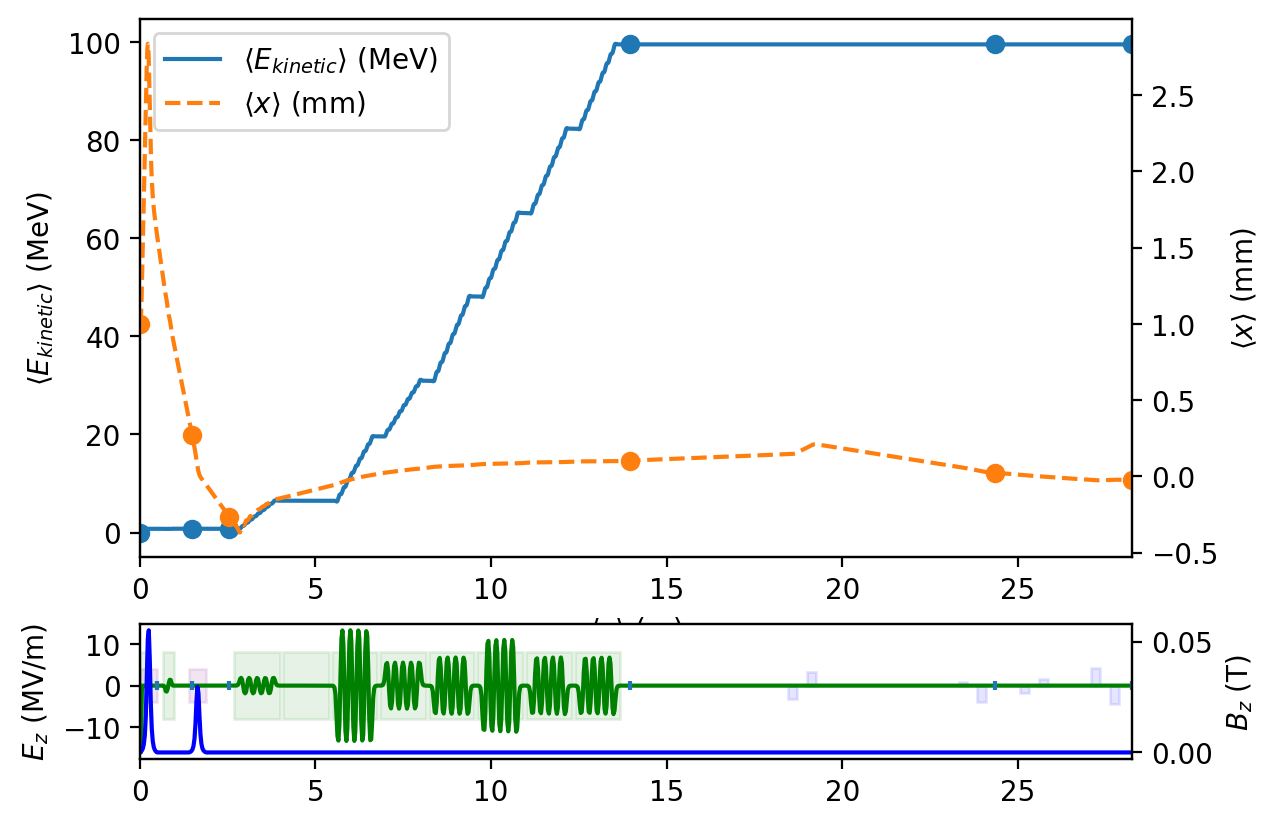

In [18]:
P0 = single_particle(pz=1e-9, x=1e-3)
#P0 = single_particle(pz=1e-9, x=0)

I = Impact(initial_particles=P0)
stop_ele = I.lattice.pop(-1)
I.lattice.pop(1) # Remove the drift
I.input['lattice'] =  [timestep_ele] + I.lattice + deepcopy(LAT) + [stop_ele]

# Make a list of s
for elename in ['YAG01B', 'CM01BEG', 'BEAM0', 'OTR0H04']:
    
    s = tao.ele_head(elename)['s']
    name = elename.split('_')[0]
    ele = new_write_beam(name=name, s=s, ref_eles=I.lattice) # ref_eles will ensure that there are no naming conflicts
    I.add_ele(ele)

#I.lattice.insert(1, gun)
#I.lattice.insert(2, sol1)
I.input['fieldmaps'].update(FIELDMAPS)

I.ele_bookkeeper()

I.header['Dt'] = 5e-13

I.ele['stop_1']['s'] = ZSTOP
I.header['Bcurr'] = 0 # Turn off SC
I.verbose=False

I.header['Flagerr'] = 1 # Allow offsets
I.header['Flagimg'] = 1 # Cathode start
I.header['Zimage'] = 0.12 # Conservative image charge distance
I.header['Nemission'] = 900 # for cathode start

#I['SOL1B:x_offset'] = 1e-3
I.run()
#I.track1(x0=0)
I.plot('mean_kinetic_energy', y2='mean_x')
#I.configure()
#I.write_input()
#I.plot(xlim=(0,1))

In [19]:
I.particles

{'initial_particles': <ParticleGroup with 1 particles at 0x16a343be0>,
 'final_particles': <ParticleGroup with 1 particles at 0x16a3439d0>,
 'YAG01B': <ParticleGroup with 1 particles at 0x16a343c10>,
 'CM01BEG': <ParticleGroup with 1 particles at 0x283bda790>,
 'BEAM0': <ParticleGroup with 1 particles at 0x283bda670>,
 'OTR0H04': <ParticleGroup with 1 particles at 0x283bda730>}

In [20]:
!cat {I.path}/ImpactT.in

! Impact-T input file
!Npcol Nprow
1 1
!Dt Ntstep Nbunch
5e-13 1000000 1
!Dim Np Flagmap Flagerr Flagdiag Flagimg Zimage
6 1 1 1 2 1 0.12
!Nx Ny Nz Flagbc Xrad Yrad Perdlen
32 32 32 1 0.015 0.015 45.0
!Flagdist Rstartflg Flagsbstp Nemission Temission
16 0 0 900 3.372134870829164e-26
!sigx(m) sigpx muxpx xscale pxscale xmu1(m) xmu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigy(m) sigpy muxpy yscale pyscale ymu1(m) ymu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigz(m) sigpz muxpz zscale pzscale zmu1(m) zmu2
0.0001 0.0 0.0 1.0 1.0 0.0 0
!Bcurr Bkenergy Bmass Bcharge Bfreq Tini
0.0 1.0 510998.95 -1.0 1000000000.0 -1.686067435414582e-26
!=================== LATTICE ===================
0 0 0 -4 0.0 0.0 0.5 1e-12 /!name:change_timestep_1
0 0 0 -5 0.0 0.0 -1000.0 /!name:2d_to_3d_spacecharge
0.17475 0 0 105 0.0 20000000.0 185714285.7142857 179.88820577738858 1 0.15 0.0 0.0 0.0 0.0 0.0 0 /!name:RFGUNB
0.48 0 0 105 0.00653 0 0 0.0 2 0.15 0.0 0.0 0.0 0.0 0.0 0.0559 /!name:SOL1B
0.3 0 0 105 0.659116 1800000.0 13000000

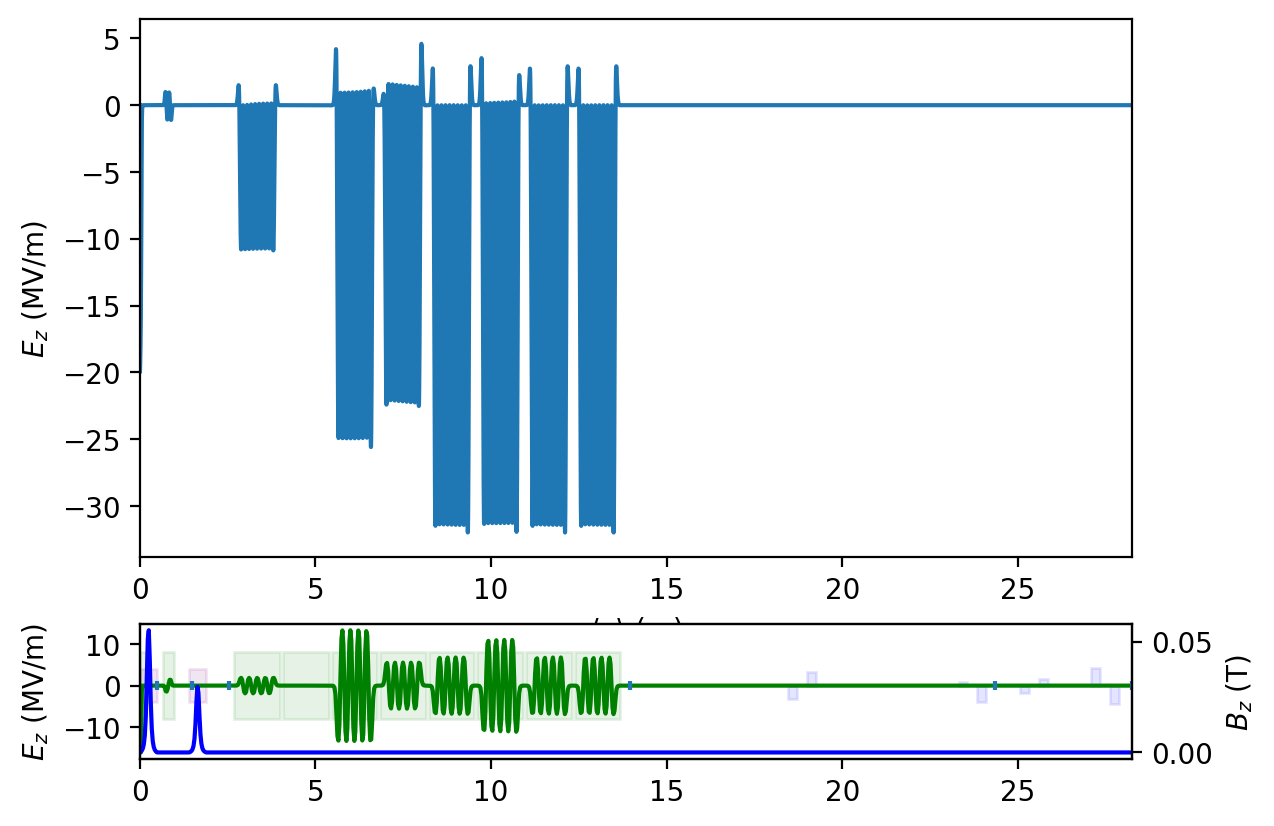

In [21]:
I.plot('Ez')

In [22]:
# Check reload
# I2 = Impact(f'{I.path}/ImpactT.in')
# I2.configure()
# I2.run()
# I2.plot('mean_kinetic_energy', y2='mean_x')

CPU times: user 283 ms, sys: 68.1 ms, total: 351 ms
Wall time: 1.45 s


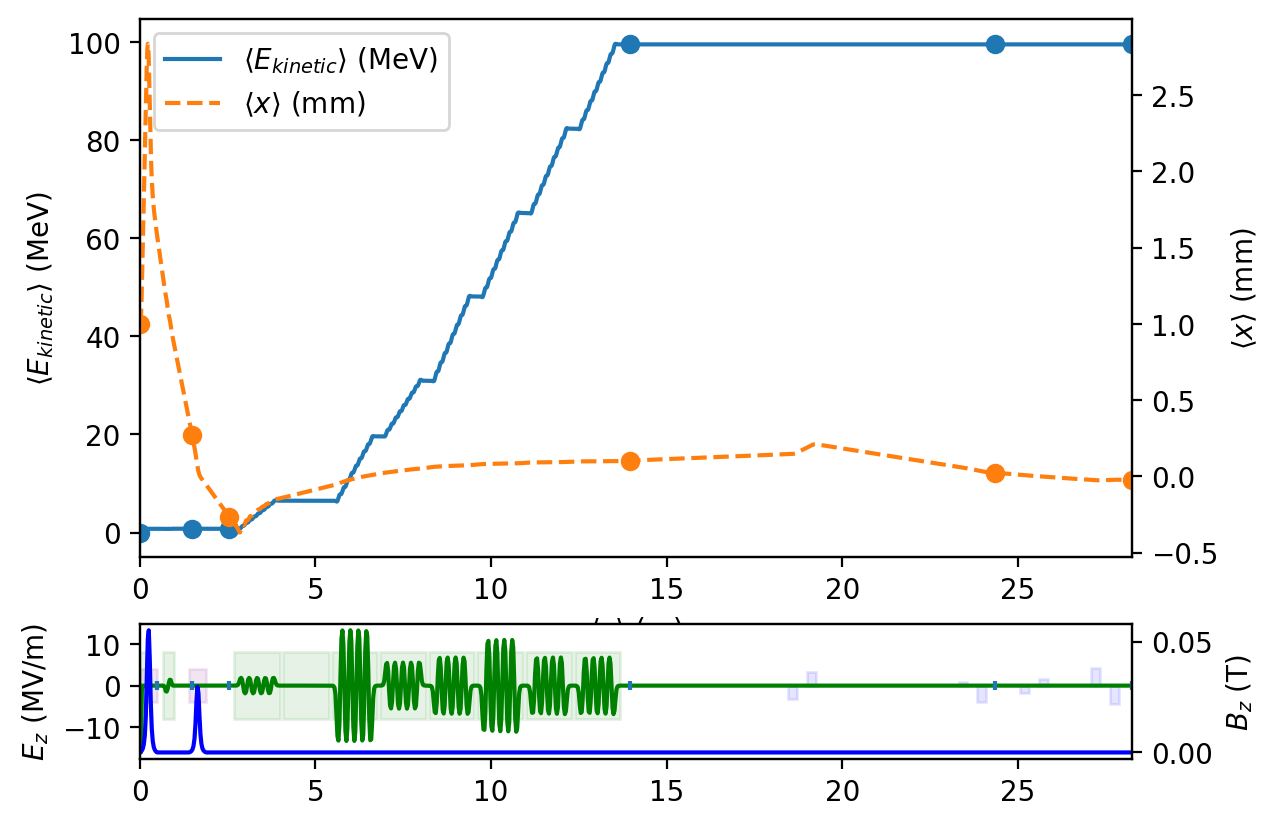

In [23]:
%%time
Iout = I.copy()
#Iout.total_charge = 100e-12 # Restore for SC calc
Iout.write_input(path=OUTPATH)
Iout.configure()
Iout.track1(x0=1e-3)
Iout.plot('mean_kinetic_energy', y2='mean_x')

# Compare Impacts

In [24]:
%%time
I1 = Impact(os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1/ImpactT.in'))
Impact.command_env     = 'IMPACTT_BIN'
Impact.command_mpi_env = 'IMPACTT_MPI_BIN'
#I1.stop = 0.25
I1.track1(x0=1e-3)

CPU times: user 175 ms, sys: 74.5 ms, total: 249 ms
Wall time: 1.07 s


<ParticleGroup with 1 particles at 0x285a7b7c0>

In [25]:
%%time
I2 = Impact(os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1new/ImpactT.in'))
Impact.command_env     = 'JI_IMPACTT_BIN'
Impact.command_mpi_env = 'JI_IMPACTT_MPI_BIN'
#I2.stop = 0.25
I2.track1(x0=1e-3) 

CPU times: user 173 ms, sys: 59.2 ms, total: 232 ms
Wall time: 1.32 s


<ParticleGroup with 1 particles at 0x2859dfbe0>

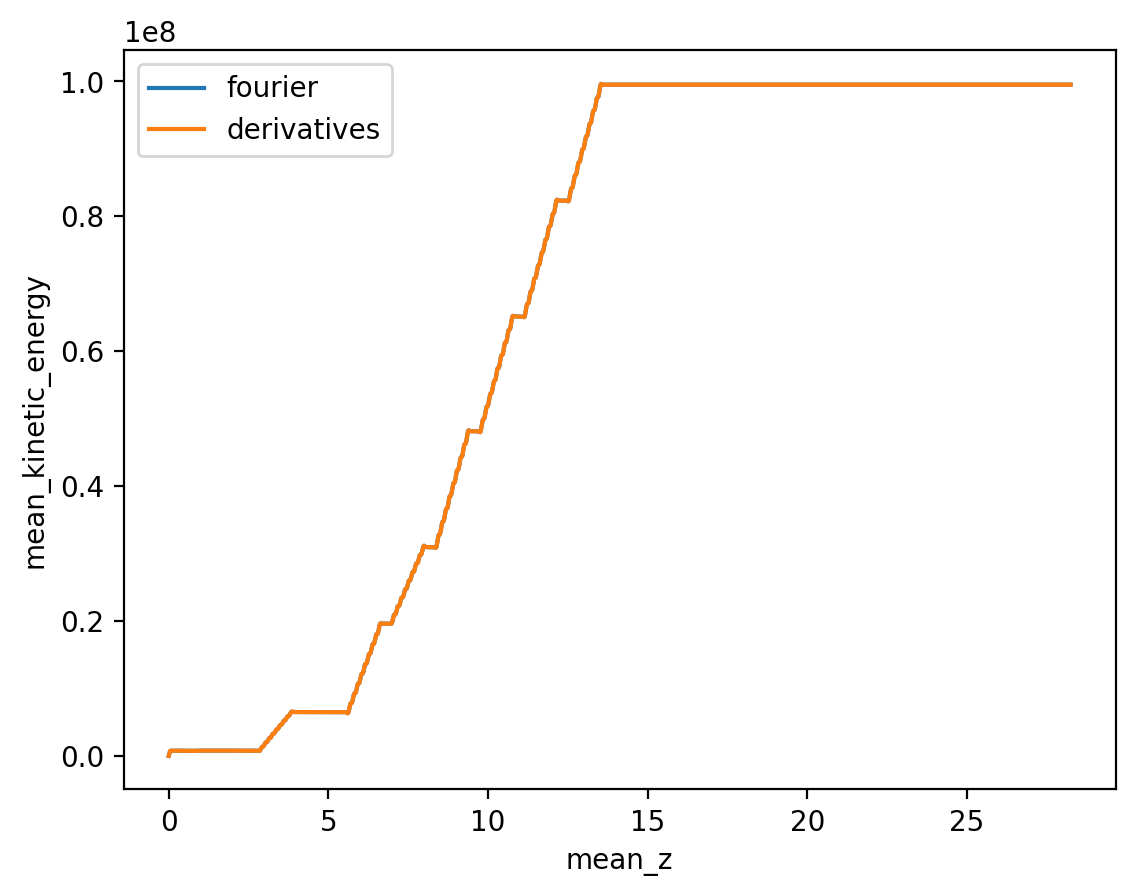

In [26]:
def compare(ykey='mean_x', xkey='mean_z'):
    
    
    fig, ax = plt.subplots()
    for name, I in ( ('fourier', I1), ('derivatives', I2)):
        x = I.stat(xkey)
        y = I.stat(ykey)
        ax.plot(x, y, label=name)
        
    plt.legend()
    ax.set_xlabel(xkey)
    ax.set_ylabel(ykey)
        
compare('mean_kinetic_energy')

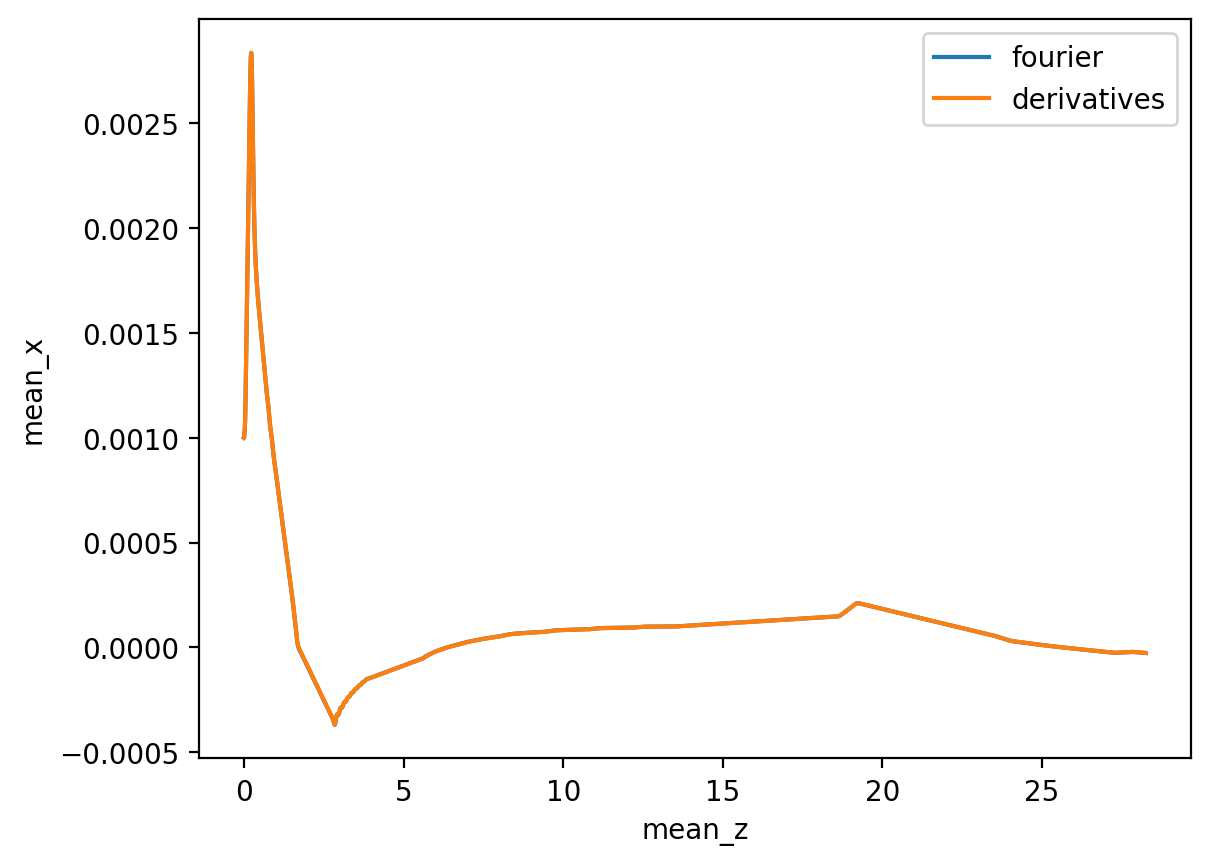

In [27]:
compare('mean_x')

# Check tracking

In [28]:
from pytao import Tao
from pytao.misc.markers import make_markers
from pmd_beamphysics import ParticleGroup
import pandas as pd
import numpy as np
import os


P0FILE = 'test.h5'
P0.write(P0FILE)

In [29]:
LATFILE = 'lat.bmad'
MARKERFILE = 'markers.bmad'

slist = np.linspace(0, ZSTOP, 250)
make_markers(slist, filename=MARKERFILE);

LAT = f"""
call, file = $LCLS_LATTICE/bmad/models/sc_inj/sc_inj.lat.bmad
call, file = {MARKERFILE}
"""

with open(LATFILE, 'w') as f:
    f.write(LAT)

In [30]:
%%time
tao = Tao(INIT + f' -lat {LATFILE}')
tao.cmd(f'set beam_init position_file = {P0FILE}')
#tao.cmd(f'set ele SOL1B x_offset = {X_OFFSET}')
#!tao.cmd(f'set ele SOL1B y_offset = {Y_OFFSET}')
tao.cmd('beamon')

CPU times: user 49.3 s, sys: 1.37 s, total: 50.7 s
Wall time: 50.5 s


['[WARNING] tao_beam_track:',
 '    Beam parameters not computed at: BEGINNING  (0)',
 '    [This will happen with round beams. Ignore this problem if the beam parameters at problem locations are not needed.]',
 '    The singular sigma matrix is:',
 '       -8.6885252E-23  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  3.8163738E-20',
 '        0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00',
 '        0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00',
 '        0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00',
 '        0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00',
 '        3.8163738E-20  0.0000000E+00  0.0000000E+00  0.0000000E+00  0.0000000E+00  3.5522685E-17',
 '    Will not print any more singular sigma matrices for this track...']

In [31]:
ix = tao.lat_list('marker::*', 'ele.ix_ele')
df = pd.DataFrame(map(tao.bunch_params, ix))

PG1 = [ ParticleGroup(data=tao.bunch_data(i)) for i in ix]
len(PG1)

275

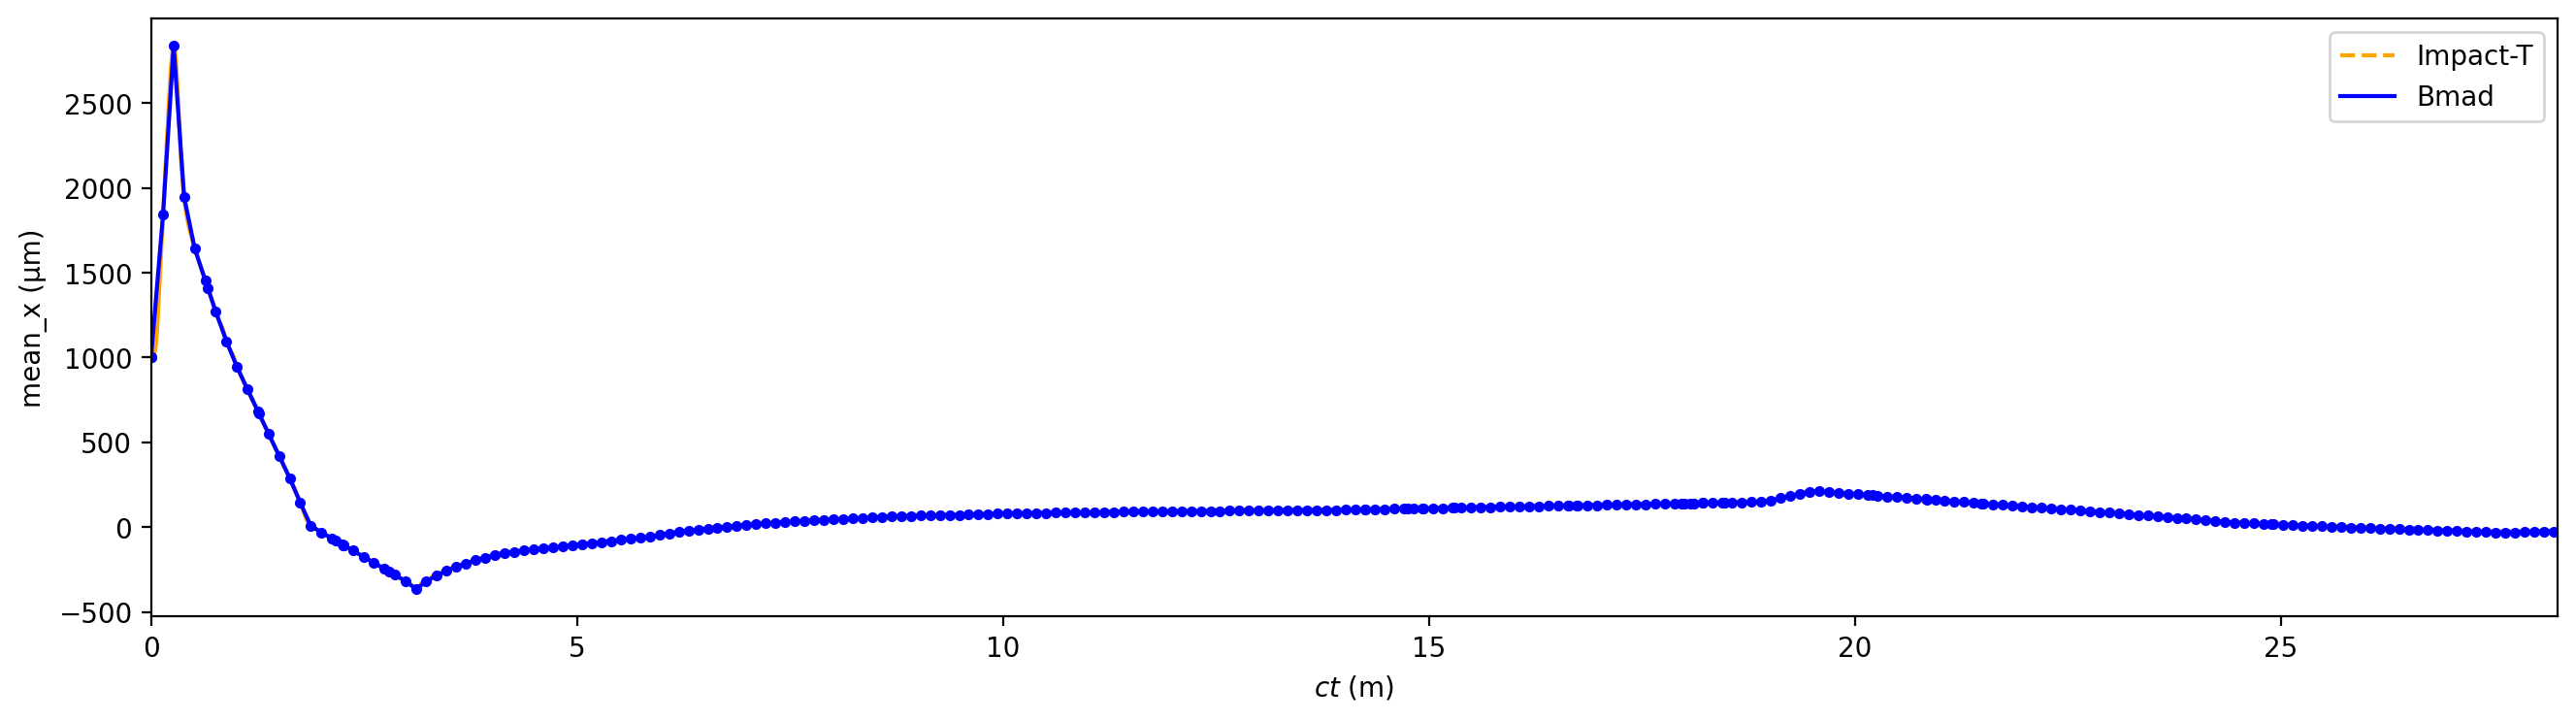

In [32]:
# Traces can be made by gathering the coordinate arrays

from matplotlib.lines import Line2D


def compare(
    ykey = 'mean_x',
    yscale = 1e6,
    yunit = r'µm'):
    
    fig, ax = plt.subplots(figsize=(16,4))
    ylabel = f'{ykey} ({yunit})'
    
    ax.plot(
         I.stat('t')*299792458,
        I.stat(ykey)*yscale,
        color='orange'
    )
        
    
    ax.plot(
        [P.t*299792458 for P in  PG1],
        [P[ykey]*yscale  for P in  PG1], color='blue', label='Bmad', marker='.',
    )
    
    ax.set_xlim(0, ZSTOP)
    #ax.set_ylim(0.5e6, 2e6)
    
    custom_lines = [Line2D([0], [0], color='orange', linestyle='--'),
                    Line2D([0], [0], color='blue')]
    ax.legend(custom_lines, ['Impact-T', 'Bmad'])
    
    ax.set_xlabel(f'$ct$ (m)')
    ax.set_ylabel(ylabel)
    #ax.set_ylim(0, 1200)
    #plt.title('Astra (red), Bmad (Blue) with fine Astra fieldmap')
    plt.savefig(f'sc_inj-Bmad-Impact-comparison-{ykey}.png', bbox_inches='tight', dpi=150)
compare()

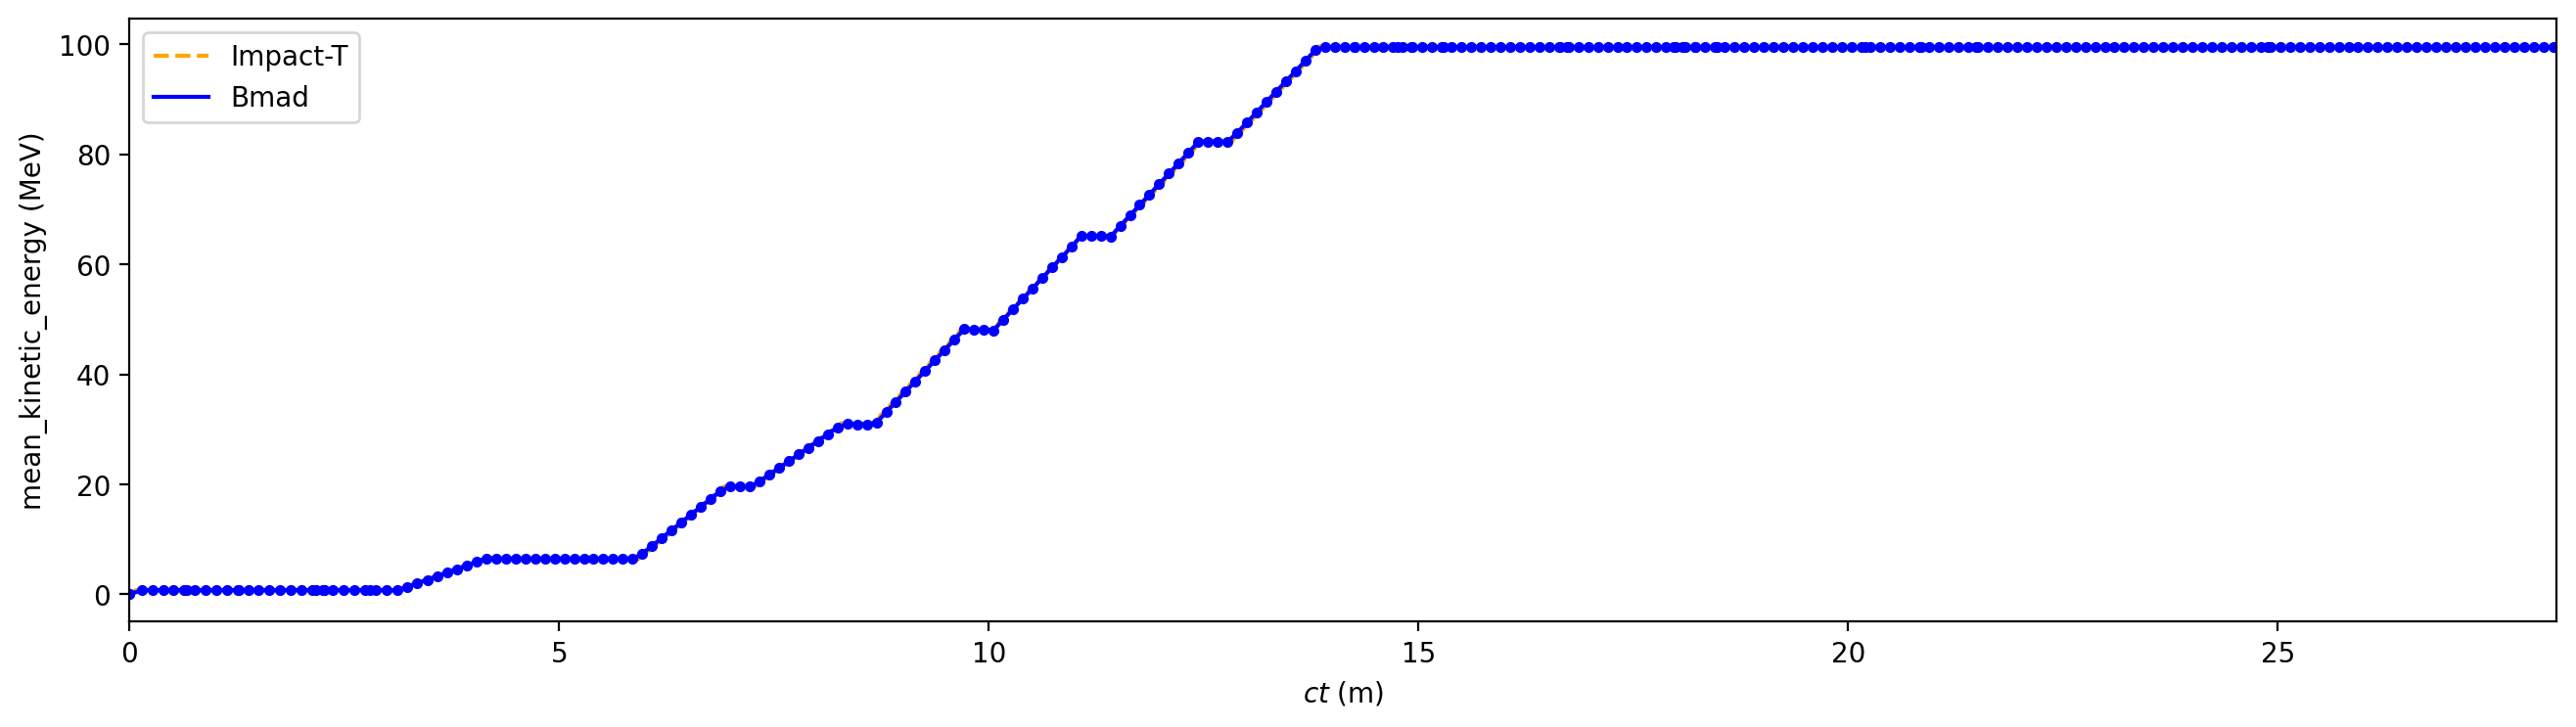

In [33]:
compare('mean_kinetic_energy', yscale=1e-6, yunit='MeV')